# Race Incidents - Safety Cars, Red Flags, and Fatal Accidents

Dataset from https://www.kaggle.com/datasets/jtrotman/formula-1-race-events

Questions:

- more safety cars at certain tracks?

In [8]:
# load packages
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.graph_objects as go
from plotly import express as px
# from plotly.subplots import make_subplots

In [5]:
# load data
safety_cars = pd.read_csv("data/f1_race_events/safety_cars.csv")
red_flags = pd.read_csv("data/f1_race_events/red_flags.csv")
fatal_accidents_drivers = pd.read_csv("data/f1_race_events/fatal_accidents_drivers.csv")

# add year column
safety_cars["Year"] = safety_cars["Race"].str[0:4]
red_flags["Year"] = safety_cars["Race"].str[0:4]


# convert date in fatal accidents dataframe
fatal_accidents_drivers["Date"] = pd.to_datetime(fatal_accidents_drivers["Date Of Accident"], format="%m/%d/%y")

# convert years in the future back to the 1900s
fatal_accidents_drivers.loc[fatal_accidents_drivers["Date"].dt.year > 2025, "Date"] -= pd.DateOffset(years=100)

# add year column
fatal_accidents_drivers["Year"] = fatal_accidents_drivers["Date"].dt.year

## Safety Cars

In [6]:
# reasons for safety cars
safety_cars["Cause"].value_counts()

Cause
Accident                191
Stranded car             83
Rain                     27
Debris from accident     25
Debris from car           9
Two accidents             9
Multiple accidents        4
Man on track              3
Debris                    3
Stranded car/Rain         2
Loose drain cover         2
Two stranded cars         2
Accident/Rain             1
Four stranded cars        1
Three accidents           1
Accidents                 1
Vehicle on track          1
Name: count, dtype: int64

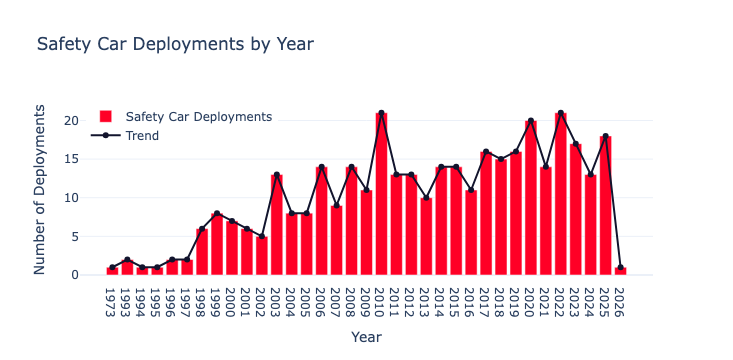

In [10]:
# safety car deployments per year

# group by year and count values
deployments_per_year = safety_cars['Year'].value_counts().sort_index()

# prepare x and y values
years = deployments_per_year.index.tolist()
counts = deployments_per_year.values.tolist()

# years with fatal accidents
fatal_years = fatal_accidents_drivers['Year'].dropna().astype(int).unique().tolist()

# bar colors if fatal accident
bar_colors = ["yellow" if y in fatal_years else "#FF0026" for y in years]

# create figure
fig = go.Figure()

# add bar trace
fig.add_trace(go.Bar(
    x=years,
    y=counts,
    name='Safety Car Deployments',
    marker_color=bar_colors
    #marker_color="#FF0026"
))

# add line trace
fig.add_trace(go.Scatter(
    x=years,
    y=counts,
    name='Trend',
    mode='lines+markers',
    line=dict(color="#12142D", width=2)
))

# add titles and update layout
fig.update_layout(
    title='Safety Car Deployments by Year',
    xaxis_title='Year',
    yaxis_title='Number of Deployments',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99)
)

fig.show()

# halo introduced in 2018 after Jules Bianchi's fatal accident in 2014

In [31]:
# are there more safety car deployments at certain tracks?

safety_cars["Country"] = safety_cars["Race"].str[5:]

safety_cars["Country"].value_counts()

# I wish I could make a proportion ...

Country
Canadian Grand Prix          32
Australian Grand Prix        31
Monaco Grand Prix            25
British Grand Prix           23
Belgian Grand Prix           22
Singapore Grand Prix         22
Brazilian Grand Prix         21
Austrian Grand Prix          14
Japanese Grand Prix          14
Chinese Grand Prix           13
German Grand Prix            11
Italian Grand Prix           10
United States Grand Prix     10
Azerbaijan Grand Prix         9
Bahrain Grand Prix            9
Spanish Grand Prix            8
Hungarian Grand Prix          7
Korean Grand Prix             7
Russian Grand Prix            7
São Paulo Grand Prix          7
Dutch Grand Prix              6
Abu Dhabi Grand Prix          6
Malaysian Grand Prix          6
European Grand Prix           5
Qatar Grand Prix              5
Saudi Arabian Grand Prix      5
Emilia Romagna Grand Prix     4
Mexico City Grand Prix        3
French Grand Prix             3
Tuscan Grand Prix             3
Miami Grand Prix              2


## Fatal Accidents

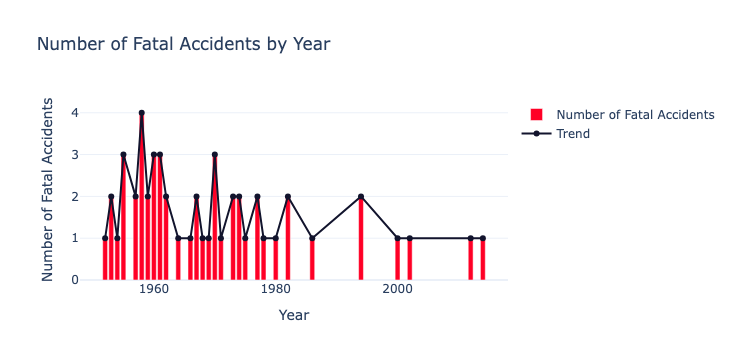

In [11]:
# fatal accidents per year
fatalities_per_year = fatal_accidents_drivers["Year"].value_counts().sort_index()

# prepare x and y values
years = fatalities_per_year.index.tolist()
counts = fatalities_per_year.values.tolist()

# create figure
fig = go.Figure()

# add bar trace
fig.add_trace(go.Bar(
    x=years,
    y=counts,
    name='Number of Fatal Accidents',
    marker_color="#FF0026"
))

# add line trace
fig.add_trace(go.Scatter(
    x=years,
    y=counts,
    name='Trend',
    mode='lines+markers',
    line=dict(color="#12142D", width=2)
))

# add titles and update layout
fig.update_layout(
    title='Number of Fatal Accidents by Year',
    xaxis_title='Year',
    yaxis_title='Number of Fatal Accidents',
    template='plotly_white',
    #legend=dict(x=0.01, y=0.99)
)

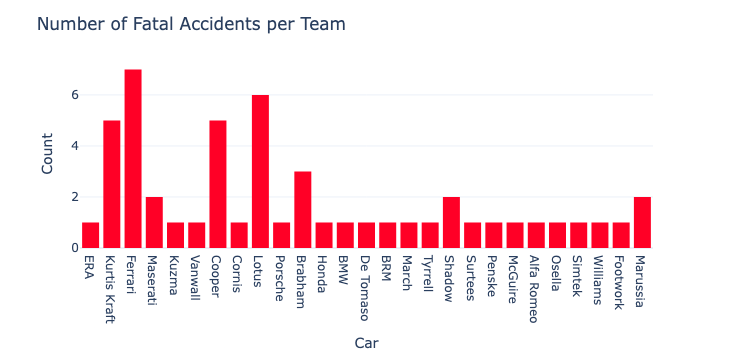

In [14]:
# fatal accidents for each team
fig = px.histogram(fatal_accidents_drivers,
                   x="Car",
)

fig.update_layout(
    yaxis_title="Count",
    title = "Number of Fatal Accidents per Team",
    template="plotly_white",
)

fig.update_traces(
    marker_color="#FF0026"
)

fig.show()

In [20]:
# closer look at fatal accidents
fatal_accidents_drivers[fatal_accidents_drivers["Car"] == "Ferrari"]

fatal_accidents_drivers[fatal_accidents_drivers["Car"] == "Lotus"]

fatal_accidents_drivers[fatal_accidents_drivers["Car"] == "Kurtis Kraft"]

,Driver,Age,Date Of Accident,Event,Car,Session,Date,Year
1,Chet Miller,50.0,5/15/53,1953 Indianapolis 500,Kurtis Kraft,Practice,1953-05-15,1953
6,Bill Vukovich,36.0,5/30/55,1955 Indianapolis 500,Kurtis Kraft,Race,1955-05-30,1955
8,Keith Andrews,36.0,5/15/57,1957 Indianapolis 500,Kurtis Kraft,Practice,1957-05-15,1957
9,Pat O'Connor,29.0,5/30/58,1958 Indianapolis 500,Kurtis Kraft,Race,1958-05-30,1958
13,Jerry Unser Jr.,26.0,5/17/59,1959 Indianapolis 500,Kurtis Kraft,Pre-race test,1959-05-17,1959


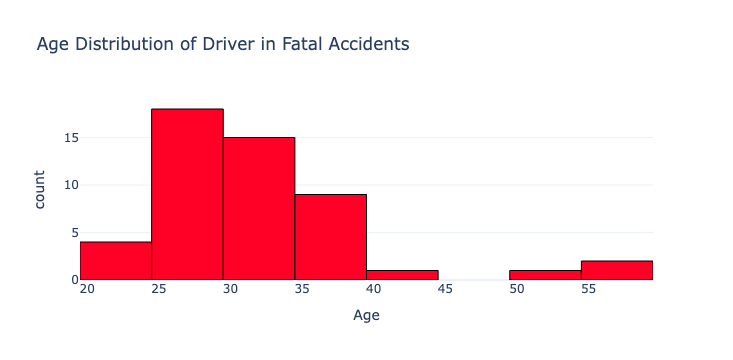

In [21]:
# ages of drivers in fatal accidents
fig = px.histogram(
    fatal_accidents_drivers,
    x='Age',
    nbins=10,  # adjust for granularity
    title="Age Distribution of Driver in Fatal Accidents",
    template="plotly_white"
)

fig.update_traces(marker_line_width=1, 
                  marker_line_color="black",
                 marker_color="#FF0026")

fig.show()

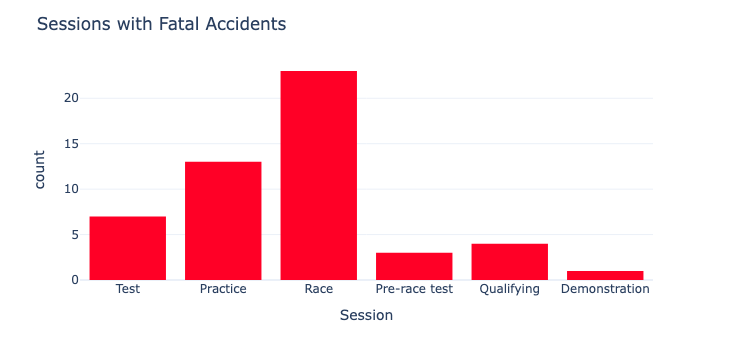

In [22]:
# type of session
fig = px.histogram(fatal_accidents_drivers,
                   x="Session",
)

fig.update_layout(
    template="plotly_white",
    title = "Sessions with Fatal Accidents"
)

fig.update_traces(
    marker_color="#FF0026"
)

fig.show()

## Safety Cars and Fatal Accidents

In [24]:
# safety_cars['Year'] = pd.to_numeric(safety_cars['Year'], errors='coerce')
# fatal_accidents_drivers['Year'] = pd.to_numeric(fatal_accidents_drivers['Year'], errors='coerce')

# safety car deployments per year
deployments_per_year = safety_cars['Year'].value_counts().sort_index()

# fatal accidents per year
fatal_accidents_per_year = fatal_accidents_drivers['Year'].value_counts().sort_index()

# combine into one DataFrame, aligning years
combined_df = pd.DataFrame({
    'Safety Cars': deployments_per_year,
    'Fatal Accidents': fatal_accidents_per_year
}).fillna(0)  # Fill missing values with 0

# ensure index is integer year
combined_df.index = combined_df.index.astype(int)
combined_df.sort_index(inplace=True)

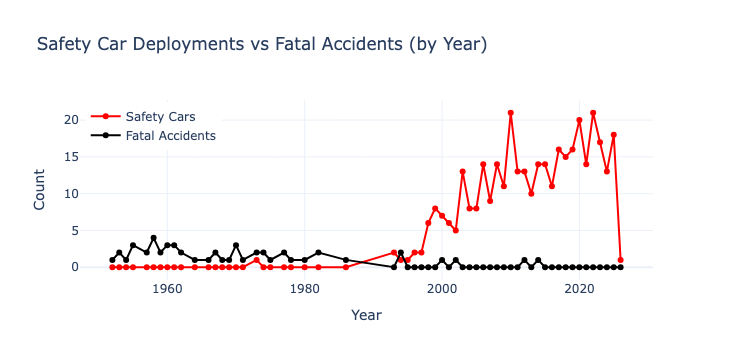

In [25]:
# safety car deployments and fatal accidents over time
fig = go.Figure()

# line for safety car deployments
fig.add_trace(go.Scatter(
    x=combined_df.index,
    y=combined_df['Safety Cars'],
    name='Safety Cars',
    mode='lines+markers',
    line=dict(color='red', width=2)
))

# line for fatal accidents
fig.add_trace(go.Scatter(
    x=combined_df.index,
    y=combined_df['Fatal Accidents'],
    name='Fatal Accidents',
    mode='lines+markers',
    line=dict(color='black', width=2)
))

# layout customization
fig.update_layout(
    title='Safety Car Deployments vs Fatal Accidents (by Year)',
    xaxis_title='Year',
    yaxis_title='Count',
    template='plotly_white',
    legend=dict(x=0.01, y=0.99),
    hovermode='x unified'
)

fig.show()